# VI. Anomaly Detection: Identifying Citation Manipulation
This notebook aims to detect suspicious behavior. We identify records that exhibit patterns consistent with academic manipulation, such as citation rings or self-citation stacking.

## 1. Imports and Initial Setup
We load the processed data and perform initial preparations. To prevent highly skewed counts from dominating distance-based models, we apply a log-transformation (`log(x+1)`) to the `authorCount` and `referenceCount` features.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics.pairwise import cosine_similarity
import torch
import torch.nn as nn
import torch.optim as optim


In [2]:
# Loads dataset and extracts base metadata columns
# @param filePath - Path to processed parquet file
# @returns - DataFrame containing analytical data
def loadAnomalyData(filePath):
    analyticalData = pd.read_parquet(filePath)
    analyticalData["authorCount"] = analyticalData["authors"].apply(lambda authorList: len(authorList) if authorList is not None else 0)
    analyticalData["referenceCount"] = analyticalData["references"].apply(lambda refList: len(refList) if refList is not None else 0)
    # Log-transform highly skewed count features
    analyticalData["logAuthorCount"] = np.log1p(analyticalData["authorCount"])
    analyticalData["logReferenceCount"] = np.log1p(analyticalData["referenceCount"])
    return analyticalData

anomalyData = loadAnomalyData("../../data/processed_dblp.parquet")

baseColumns =["id", "venue", "year", "n_citation", "authors", "references", "authorCount", "referenceCount", "logAuthorCount", "logReferenceCount"]
textColumns =[col for col in anomalyData.columns if col not in baseColumns]


## 2. Feature Engineering for Fraud Detection
We create three features designed to capture signals of manipulation.

### 2.1. Self-Citation Ratio
Calculates the proportion of a paper's references that share at least one author with the paper itself. A consistently high ratio is a strong indicator of citation stacking.

In [3]:
# Computes self-citation ratio for all records
# @param dataFrame - Dataset containing authors and references
# @returns - List of self-citation ratios
def computeSelfCitationRatio(dataFrame):
    # Map paper IDs to their author sets for efficient lookup
    idToAuthors = {}
    for _, row in dataFrame.iterrows():
        if row["authors"] is not None:
            validAuthors = [author for author in row["authors"] if author is not None]
            idToAuthors[row["id"]] = set(validAuthors)
        else:
            idToAuthors[row["id"]] = set()
            
    ratios =[]
    # Iterate through papers to calculate ratio
    for _, row in dataFrame.iterrows():
        references = row["references"]
        if references is None or len(references) == 0:
            ratios.append(0.0)
            continue
        
        paperAuthors = idToAuthors.get(row["id"], set())
        if len(paperAuthors) == 0:
            ratios.append(0.0)
            continue
            
        selfCites = 0
        for referenceId in references:
            referenceAuthors = idToAuthors.get(referenceId, set())
            # Check for common authors between paper and reference
            if len(paperAuthors.intersection(referenceAuthors)) > 0:
                selfCites += 1
                
        ratios.append(selfCites / len(references))
        
    return ratios

anomalyData["selfCiteRatio"] = computeSelfCitationRatio(anomalyData)


### 2.2. Topic Mismatch
Calculates the cosine distance between a paper's TF-IDF vector and the average TF-IDF vector of its publication venue. A high distance suggests the paper's topic is unrelated to its venue, a potential sign of publication in a low-quality or predatory journal.

In [4]:
# Computes cosine distance between paper and venue average topic
# @param dataFrame - Dataset containing venues and text features
# @param featureColumns - List of textual feature columns
# @returns - Array of distance scores
def computeTopicMismatch(dataFrame, featureColumns):
    # Calculate mean TF-IDF vector for each venue
    venueMeans = dataFrame.groupby("venue")[featureColumns].transform("mean")
    paperVectors = dataFrame[featureColumns].values
    venueVectors = venueMeans.values
    
    # Compute cosine similarity element-wise to avoid memory overload
    normsPaper = np.linalg.norm(paperVectors, axis=1)
    normsVenue = np.linalg.norm(venueVectors, axis=1)
    
    validIndices = (normsPaper > 0) & (normsVenue > 0)
    dotProduct = np.sum(paperVectors * venueVectors, axis=1)
    
    similarity = np.zeros(len(dataFrame))
    similarity[validIndices] = dotProduct[validIndices] / (normsPaper[validIndices] * normsVenue[validIndices])
    
    # Clip to handle floating point inaccuracies and convert to distance
    similarity = np.clip(similarity, -1.0, 1.0)
    distance = 1.0 - similarity
    
    return np.clip(distance, 0.0, 2.0)

anomalyData["topicMismatch"] = computeTopicMismatch(anomalyData, textColumns)


### 2.3. Network Density
Measures the local clustering coefficient of each paper in an undirected citation graph. A high coefficient means a paper's references are also highly interconnected, forming a dense clique characteristic of a citation ring.

In [5]:
# Computes local clustering coefficient on citation graph
# @param dataFrame - Dataset containing id and references
# @returns - Series of clustering coefficients
def computeNetworkDensity(dataFrame):
    # Build undirected graph where edges represent citations
    citationGraph = nx.Graph()
    for _, row in dataFrame.iterrows():
        nodeId = row["id"]
        citationGraph.add_node(nodeId)
        if row["references"] is not None:
            for referenceId in row["references"]:
                citationGraph.add_edge(nodeId, referenceId)
                
    # Calculate clustering for all nodes
    clusteringCoefficients = nx.clustering(citationGraph)
    return dataFrame["id"].map(clusteringCoefficients).fillna(0.0)

anomalyData["networkDensity"] = computeNetworkDensity(anomalyData)


## 3. Standard Anomaly Detection Models
We apply two standard, non-neural network models to the engineered features. Both are configured to flag the top 1% of the data as anomalous. We do exclude `n_citation` as a feature, as the goal is to find anomalies, not highly cited papers.

In [6]:
# Define features for anomaly detection (excluding n_citation)
anomalyFeatures =["selfCiteRatio", "topicMismatch", "networkDensity", "logAuthorCount", "logReferenceCount"]
featureMatrixRaw = anomalyData[anomalyFeatures]

scaler = StandardScaler()
featureMatrixScaled = scaler.fit_transform(featureMatrixRaw)
featureDataFrame = pd.DataFrame(featureMatrixScaled, columns=anomalyFeatures)

# Isolation Forest model
isolationForest = IsolationForest(contamination=0.01, random_state=64)
anomalyData["isoForestFlag"] = isolationForest.fit_predict(featureMatrixScaled)

# One-Class SVM model
oneClassSvm = OneClassSVM(nu=0.01)
anomalyData["ocsvmFlag"] = oneClassSvm.fit_predict(featureMatrixScaled)


## 4. Deep Learning Anomaly Detection (Autoencoder)
We use an autoencoder to compress and then reconstruct the feature vectors of normal data points. Anomalous points should have a high reconstruction error (Mean Squared Error). We train the model and then flag the 1% of records with the highest error.

In [7]:
# Defines autoencoder architecture
class FraudAutoencoder(nn.Module):
    # Defines encoder and decoder layers
    def __init__(self, inputSize):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(inputSize, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 4) # Bottleneck layer
        )
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, inputSize)
        )
    
    # Defines forward pass logic
    def forward(self, inputData):
        encoded = self.encoder(inputData)
        decoded = self.decoder(encoded)
        return decoded

tensorFeatures = torch.tensor(featureMatrixScaled, dtype=torch.float32)
inputDimension = featureMatrixScaled.shape[1]
autoencoderModel = FraudAutoencoder(inputDimension)


In [8]:
lossFunction = nn.MSELoss()
optimizer = optim.Adam(autoencoderModel.parameters(), lr=0.005)
epochCount = 100

autoencoderModel.train()
for epoch in range(epochCount):
    # Forward pass: reconstruct data
    reconstructedData = autoencoderModel(tensorFeatures)
    
    # Calculate reconstruction error (loss)
    loss = lossFunction(reconstructedData, tensorFeatures)
    
    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1}/{epochCount} Loss: {loss.item():.4f}")

autoencoderModel.eval()
with torch.no_grad():
    # Calculate final reconstruction errors on all data
    finalReconstruction = autoencoderModel(tensorFeatures)
    reconstructionErrors = torch.mean((finalReconstruction - tensorFeatures) ** 2, dim=1).numpy()

# Flag top 1% with highest error
anomalyData["reconstructionError"] = reconstructionErrors
errorThreshold = np.percentile(reconstructionErrors, 99)
anomalyData["autoencoderFlag"] = np.where(reconstructionErrors >= errorThreshold, -1, 1)


d:\Users\FangMage\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch 20/100 Loss: 0.8762
Epoch 40/100 Loss: 0.5868
Epoch 60/100 Loss: 0.4006
Epoch 80/100 Loss: 0.2671
Epoch 100/100 Loss: 0.1087


## 5. Results
We visualize the distribution of reconstruction errors to confirm the model has separated a clear tail of anomalies. We isolate the records flagged as anomalous by both the Isolation Forest and the Autoencoder.

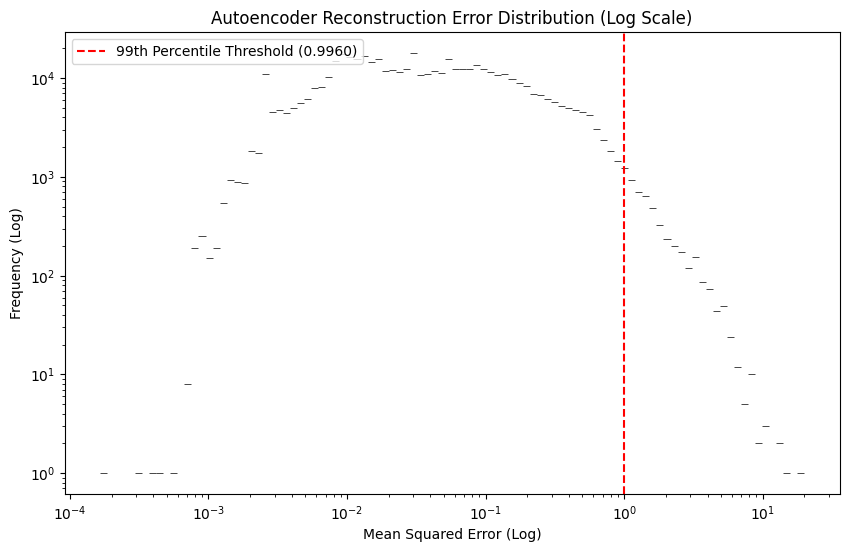

Total overlapping anomalies flagged: 1663

Top 5 Anomalous Records for Manual Review:
                                                    venue    year  n_citation  \
448442  PRACTICE AND EXPERIENCE IN ADVANCED RESEARCH C...  2021.0           2   
104023                                               CoRR  2023.0           1   
360479                                               None  2003.0          11   
487122             Optical Fiber Communication Conference  2014.0           8   
415075                                            Sensors  2021.0          18   

        selfCiteRatio  topicMismatch  networkDensity  authorCount  
448442            0.5       0.425354             1.0           31  
104023            1.0       0.643916             0.0           57  
360479            1.0       0.840015             0.0           42  
487122            1.0       0.582752             1.0           17  
415075            0.5       0.854577             1.0           10  


In [ ]:
# Plot error distribution
plt.figure(figsize=(10, 6))
sns.histplot(anomalyData["reconstructionError"], bins=100, kde=False, log_scale=(True, True))
plt.axvline(x=errorThreshold, color="red", linestyle="--", label=f"99th Percentile Threshold ({errorThreshold:.4f})")
plt.title("Autoencoder Reconstruction Error Distribution (Log Scale)")
plt.xlabel("Mean Squared Error (Log)")
plt.ylabel("Frequency (Log)")
plt.legend()
plt.show()

# Isolate overlaps between models for manual review
overlapCondition = (anomalyData["isoForestFlag"] == -1) & (anomalyData["autoencoderFlag"] == -1)
flaggedAnomalies = anomalyData[overlapCondition].sort_values("reconstructionError", ascending=False)

print(f"Total overlapping anomalies flagged: {len(flaggedAnomalies)}\n")
print("Top 5 anomalous records:")

displayColumns =["venue", "year", "n_citation", "selfCiteRatio", "topicMismatch", "networkDensity", "authorCount"]
print(flaggedAnomalies[displayColumns].head(5))
